# Rent Data Cleaning and EDA

This notebook cleans raw rental listings scraped from Madlan.

The goal is to create a clean dataset with these final columns:

- City
- Neighborhood
- price
- rooms
- price_per_room
- price_per_sqm

This cleaned dataset will later be used to compare rent prices across different cities in Israel.

In [1]:
# Import libraries for data cleaning, analysis and visualization
import pandas as pd
import numpy as np
import glob
import re
import matplotlib.pyplot as plt

## 1. Project Settings

Here I define the city name and the output file name.

To reuse this notebook for another city, I only need to change these two variables.

In [2]:
# Define the city name
CITY_NAME = "Haifa"

# Define the output file name
OUTPUT_FILE = "haifa_rent_clean.csv"

# Test that the variables are working
print("City selected:", CITY_NAME)
print("Output file:", OUTPUT_FILE)

City selected: Haifa
Output file: haifa_rent_clean.csv


## 2. Load Raw CSV Files

I uploaded several CSV files scraped from Madlan using a Chrome extension.

In this step, I combine all raw CSV files into one dataframe.

In [3]:
# Find all CSV files uploaded to Colab
csv_files = glob.glob("*.csv")

# Display the list of files
csv_files

['Haifa_rent3.csv',
 'Haifa_rent1.csv',
 'Haifa_rent5.csv',
 'Haifa_rent8.csv',
 'Haifa_rent6.csv',
 'Haifa_rent4.csv',
 'Haifa_rent2.csv',
 'Haifa_rent7.csv']

In [4]:
# Create an empty list to store each CSV dataframe
raw_list = []

# Loop through every CSV file and read it
for file in csv_files:
    df = pd.read_csv(file)

    # Add the original file name for tracking
    df["original_file"] = file

    raw_list.append(df)

# Combine all CSV files into one dataframe
raw_rent = pd.concat(raw_list, ignore_index=True)

# Check the shape of the combined dataframe
raw_rent.shape

(337, 11)

In [5]:
# Preview the first rows of the raw scraped data
raw_rent.head()

,css-u1nut8 href,css-hqth87,css-q8j3hw,css-q8j3hw 2,css-q8j3hw 3,css-n4p85g,css-afgd57,original_file,blog-card__root href,css-6vad4i src,css-1cixjsh
0,https://www.madlan.co.il/listings/YEgpqK26R4Q,"‏4,600 ‏₪",3 חד׳,קומה 3,"105 מ""ר","דירה, שדרות אליהו גולומב 21, הדר עליון",NaN,Haifa_rent3.csv,NaN,NaN,NaN
1,https://www.madlan.co.il/listings/PPaqNl5DCFA,"‏3,400 ‏₪",2.5 חד׳,קומה 2,"80 מ""ר","דירה, וינגיט 3, הדר עליון",NaN,Haifa_rent3.csv,NaN,NaN,NaN
2,https://www.madlan.co.il/listings/TpARobXH3r5,"‏2,300 ‏₪",2 חד׳,קומת קרקע,"40 מ""ר","דירה, ארלוזורוב 100, הדר עליון",תיווך,Haifa_rent3.csv,NaN,NaN,NaN
3,https://www.madlan.co.il/listings/8VOrXT9sVMh,"‏3,200 ‏₪",2.5 חד׳,קומה 2,"65 מ""ר","דירה, הלל , הדר עליון",תיווך,Haifa_rent3.csv,NaN,NaN,NaN
4,https://www.madlan.co.il/listings/LtGn9aImaEM,"‏3,850 ‏₪",4 חד׳,קומה 2,"80 מ""ר","דירה, בר גיורא 46, הדר עליון",NaN,Haifa_rent3.csv,NaN,NaN,NaN


In [6]:
# Display all column names
raw_rent.columns

Index(['css-u1nut8 href', 'css-hqth87', 'css-q8j3hw', 'css-q8j3hw 2',
       'css-q8j3hw 3', 'css-n4p85g', 'css-afgd57', 'original_file',
       'blog-card__root href', 'css-6vad4i src', 'css-1cixjsh'],
      dtype='object')

## 3. Select and Rename Useful Columns

The scraped data contains messy column names.

In this step, I select the columns that contain the important rental information and create a cleaner dataframe.

In [7]:
# Create a clean dataframe
rent = pd.DataFrame()

# Add city name manually
rent["City"] = CITY_NAME

# Full raw location string
full_location = raw_rent["css-n4p85g"].astype(str)

# Extract address
rent["Address"] = (
    full_location
    .str.split(",")
    .str[0]
    .str.strip()
)

# Extract neighborhood
rent["Neighborhood"] = (
    full_location
    .str.split(",")
    .str[-1]
    .str.strip()
)

# Extract price
rent["price"] = raw_rent["css-hqth87"]

# Extract rooms
rent["rooms"] = raw_rent["css-q8j3hw"]

# Extract apartment size
rent["size_sqm"] = raw_rent["css-q8j3hw 3"]

# Preview dataframe
rent.head()

,City,Address,Neighborhood,price,rooms,size_sqm
0,NaN,דירה,הדר עליון,"‏4,600 ‏₪",3 חד׳,"105 מ""ר"
1,NaN,דירה,הדר עליון,"‏3,400 ‏₪",2.5 חד׳,"80 מ""ר"
2,NaN,דירה,הדר עליון,"‏2,300 ‏₪",2 חד׳,"40 מ""ר"
3,NaN,דירה,הדר עליון,"‏3,200 ‏₪",2.5 חד׳,"65 מ""ר"
4,NaN,דירה,הדר עליון,"‏3,850 ‏₪",4 חד׳,"80 מ""ר"


## 4. Clean Numeric Columns

The price, rooms and size columns may contain text, symbols or extra characters.

In this step, I extract only the numeric values and convert them into numeric data types.

In [8]:
# Clean price column
rent["price"] = (
    rent["price"]
    .astype(str)
    .str.replace(r"[^\d]", "", regex=True)
    .replace("", np.nan)
    .astype(float)
)

# Clean rooms column
rent["rooms"] = (
    rent["rooms"]
    .astype(str)
    .str.extract(r"(\d+\.?\d*)")[0]
    .astype(float)
)

# Clean size_sqm column
rent["size_sqm"] = (
    rent["size_sqm"]
    .astype(str)
    .str.extract(r"(\d+\.?\d*)")[0]
    .astype(float)
)

# Preview cleaned dataframe
rent.head()

,City,Address,Neighborhood,price,rooms,size_sqm
0,NaN,דירה,הדר עליון,4600.0,3.0,105.0
1,NaN,דירה,הדר עליון,3400.0,2.5,80.0
2,NaN,דירה,הדר עליון,2300.0,2.0,40.0
3,NaN,דירה,הדר עליון,3200.0,2.5,65.0
4,NaN,דירה,הדר עליון,3850.0,4.0,80.0


## 5. Clean Neighborhood Column

The neighborhood column may contain extra text.

In this step, I clean the neighborhood names and keep them as readable text.

In [9]:
# Convert neighborhood column to string and clean extra spaces
rent["Neighborhood"] = (
    rent["Neighborhood"]
    .astype(str)
    .str.strip()
)

# Replace empty or invalid values with NaN
rent["Neighborhood"] = rent["Neighborhood"].replace(["nan", "", "None"], np.nan)

rent.head()

,City,Address,Neighborhood,price,rooms,size_sqm
0,NaN,דירה,הדר עליון,4600.0,3.0,105.0
1,NaN,דירה,הדר עליון,3400.0,2.5,80.0
2,NaN,דירה,הדר עליון,2300.0,2.0,40.0
3,NaN,דירה,הדר עליון,3200.0,2.5,65.0
4,NaN,דירה,הדר עליון,3850.0,4.0,80.0


In [10]:
# Translate neighborhood names to English

# Clean neighborhood column
rent["Neighborhood"] = rent["Neighborhood"].astype(str).str.strip()

# Dictionary with neighborhood translations
neighborhood_map = {

    "הדר הכרמל": "Hadar HaCarmel",

    "הדר עליון": "Upper Hadar",

    "כרמל מערבי": "West Carmel",

    "מרכז הכרמל": "Central Carmel",

    "עיר תחתית": "Downtown Haifa",

    "נוה שאנן": "Neve Shaanan",

    "כרמל צפוני": "North Carmel",

    "יזרעאליה": "Yizre'eliya",

    "כרמל ותיק": "Old Carmel",

    "רמת התשבי": "Ramat HaTishbi",

    "תל עמל": "Tel Amal",

    "נוה פז": "Neve Paz",

    "עבאס": "Abbas",

    "ואדי ניסנאס": "Wadi Nisnas",

    "כרמל צרפתי": "French Carmel",

    "רמת הדר": "Ramat Hadar",

    "אחוזה": "Ahuza",

    "כרמליה": "Carmelia",

    "מאי": "Mai"

}

# Replace Hebrew names with English names
rent["Neighborhood"] = rent["Neighborhood"].replace(neighborhood_map)

# Preview translated neighborhoods
rent["Neighborhood"].unique()

array(['Upper Hadar', 'Hadar HaCarmel', 'Central Carmel',
       'Downtown Haifa', 'Wadi Nisnas', 'Mai', 'West Carmel',
       'Old Carmel', 'Ramat HaTishbi', 'North Carmel', 'Abbas',
       'French Carmel', "Yizre'eliya", 'Neve Shaanan', 'Neve Paz',
       'Tel Amal', 'Carmelia', 'Ahuza', 'Ramat Hadar', 'nan'],
      dtype=object)

In [14]:
rent["Neighborhood"] = rent["Neighborhood"].replace(neighborhood_map)

## 6. Remove Missing Values and Duplicates

In this step, I remove rows that do not have the essential information needed for analysis.

In [12]:
# Check missing values
rent.isna().sum()

,0
City,337
Address,0
Neighborhood,0
price,23
rooms,42
size_sqm,22


In [13]:
# Drop rows missing important columns
rent = rent.dropna(subset=["price", "rooms", "size_sqm"])

# Drop duplicated rows
rent = rent.drop_duplicates()

# Check the cleaned dataset shape
rent.shape

(201, 6)

## 7. Create KPI Columns

In this step, I create two important rent KPIs:

- price_per_room: how much each room costs on average
- price_per_sqm: how much each square meter costs on average

These metrics help compare apartments more fairly.

In [15]:
# Calculate price per room
rent["price_per_room"] = rent["price"] / rent["rooms"]

# Calculate price per square meter
rent["price_per_sqm"] = rent["price"] / rent["size_sqm"]

# Round KPI columns
rent["price_per_room"] = rent["price_per_room"].round(2)
rent["price_per_sqm"] = rent["price_per_sqm"].round(2)

rent.head()

,City,Address,Neighborhood,price,rooms,size_sqm,price_per_room,price_per_sqm
0,NaN,דירה,Upper Hadar,4600.0,3.0,105.0,1533.33,43.81
1,NaN,דירה,Upper Hadar,3400.0,2.5,80.0,1360.00,42.50
2,NaN,דירה,Upper Hadar,2300.0,2.0,40.0,1150.00,57.50
3,NaN,דירה,Upper Hadar,3200.0,2.5,65.0,1280.00,49.23
4,NaN,דירה,Upper Hadar,3850.0,4.0,80.0,962.50,48.12


## 8. Keep Final Columns

Now I keep only the final columns needed for the project.

In [16]:
# Dictionary to translate / standardize neighborhood names
neighborhood_map = {

    "הדר הכרמל": "Hadar HaCarmel",

    "הדר עליון": "Upper Hadar",

    "כרמל מערבי": "West Carmel",

    "מרכז הכרמל": "Central Carmel",

    "עיר תחתית": "Downtown Haifa",

    "נוה שאנן": "Neve Shaanan",

    "כרמל צפוני": "North Carmel",

    "יזרעאליה": "Yizre'eliya",

    "כרמל ותיק": "Old Carmel",

    "רמת התשבי": "Ramat HaTishbi",

    "תל עמל": "Tel Amal",

    "נוה פז": "Neve Paz",

    "עבאס": "Abbas",

    "ואדי ניסנאס": "Wadi Nisnas",

    "כרמל צרפתי": "French Carmel",

    "רמת הדר": "Ramat Hadar",

    "אחוזה": "Ahuza",

    "כרמליה": "Carmelia",

    "מאי": "Mai"

}

# Create translated neighborhood column
rent["Neighborhood_EN"] = rent["Neighborhood"].replace(neighborhood_map)

# Create final clean dataset
rent_final = rent[[
    "City",
    "Neighborhood_EN",
    "price",
    "rooms",
    "price_per_room",
    "price_per_sqm"
]]

# Rename translated column
rent_final = rent_final.rename(
    columns={"Neighborhood_EN": "Neighborhood"}
)

# Preview final dataset
rent_final.head()

,City,Neighborhood,price,rooms,price_per_room,price_per_sqm
0,NaN,Upper Hadar,4600.0,3.0,1533.33,43.81
1,NaN,Upper Hadar,3400.0,2.5,1360.00,42.50
2,NaN,Upper Hadar,2300.0,2.0,1150.00,57.50
3,NaN,Upper Hadar,3200.0,2.5,1280.00,49.23
4,NaN,Upper Hadar,3850.0,4.0,962.50,48.12


In [17]:
# Force city name into the final dataset
rent_final = rent_final.copy()

rent_final["City"] = "Haifa"

# Reorder columns
rent_final = rent_final[
    ["City", "Neighborhood", "price", "rooms", "price_per_room", "price_per_sqm"]
]

# Preview final dataset
rent_final.head()

,City,Neighborhood,price,rooms,price_per_room,price_per_sqm
0,Haifa,Upper Hadar,4600.0,3.0,1533.33,43.81
1,Haifa,Upper Hadar,3400.0,2.5,1360.00,42.50
2,Haifa,Upper Hadar,2300.0,2.0,1150.00,57.50
3,Haifa,Upper Hadar,3200.0,2.5,1280.00,49.23
4,Haifa,Upper Hadar,3850.0,4.0,962.50,48.12


## 9. Basic Dataset Quality Check

Before starting the analysis, I check the final dataset structure, missing values and summary statistics.

In [18]:
# Dataset information
rent_final.info()

<class 'pandas.core.frame.DataFrame'>
Index: 201 entries, 0 to 316
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   City            201 non-null    object 
 1   Neighborhood    201 non-null    object 
 2   price           201 non-null    float64
 3   rooms           201 non-null    float64
 4   price_per_room  201 non-null    float64
 5   price_per_sqm   201 non-null    float64
dtypes: float64(4), object(2)
memory usage: 19.1+ KB


In [19]:
# Check missing values in final dataset
rent_final.isna().sum()

,0
City,0
Neighborhood,0
price,0
rooms,0
price_per_room,0
price_per_sqm,0


In [20]:
# Summary statistics for numeric columns
rent_final.describe()

,price,rooms,price_per_room,price_per_sqm
count,201.000000,201.000000,201.000000,201.000000
mean,3795.119403,2.957711,1310.945920,70.470398
std,1505.271094,0.889917,416.589494,222.528333
min,1400.000000,1.500000,420.000000,17.500000
25%,2700.000000,2.000000,1066.670000,44.120000
50%,3500.000000,3.000000,1200.000000,50.770000
75%,4400.000000,3.500000,1440.000000,60.000000
max,11000.000000,6.000000,3500.000000,3200.000000


## 10. Outlier Detection

Before calculating the final KPIs, I check for unrealistic rental prices that may distort the analysis.

Some listings may contain:
- data entry mistakes
- luxury penthouses
- incorrect listing types

These outliers can heavily affect averages and charts.

In [21]:
# Display summary statistics for rent prices
rent_final["price"].describe()

,price
count,201.000000
mean,3795.119403
std,1505.271094
min,1400.000000
25%,2700.000000
50%,3500.000000
75%,4400.000000
max,11000.000000


In [22]:
# Display the most expensive listings
rent_final.sort_values(by="price", ascending=False).head(10)

,City,Neighborhood,price,rooms,price_per_room,price_per_sqm
38,Haifa,Central Carmel,11000.0,4.0,2750.00,81.48
131,Haifa,North Carmel,9350.0,3.0,3116.67,93.50
241,Haifa,Central Carmel,9200.0,4.0,2300.00,80.70
123,Haifa,North Carmel,8000.0,3.0,2666.67,76.92
130,Haifa,North Carmel,8000.0,6.0,1333.33,43.48
243,Haifa,Carmelia,8000.0,4.0,2000.00,86.96
117,Haifa,Old Carmel,7800.0,5.0,1560.00,57.78
227,Haifa,Central Carmel,7500.0,4.0,1875.00,44.12
221,Haifa,Central Carmel,7300.0,4.0,1825.00,76.84
47,Haifa,Central Carmel,7000.0,5.0,1400.00,56.00


In [23]:
# Display the cheapest listings
rent_final.sort_values(by="price", ascending=True).head(10)

,City,Neighborhood,price,rooms,price_per_room,price_per_sqm
303,Haifa,Hadar HaCarmel,1400.0,1.5,933.33,66.67
22,Haifa,Upper Hadar,1500.0,1.5,1000.00,60.00
70,Haifa,Downtown Haifa,1800.0,2.0,900.00,60.00
54,Haifa,Downtown Haifa,1950.0,2.5,780.00,43.33
97,Haifa,Hadar HaCarmel,1999.0,2.0,999.50,49.98
14,Haifa,Upper Hadar,2000.0,1.5,1333.33,50.00
274,Haifa,Hadar HaCarmel,2000.0,2.0,1000.00,40.00
277,Haifa,Hadar HaCarmel,2000.0,1.5,1333.33,52.63
68,Haifa,Downtown Haifa,2100.0,5.0,420.00,17.50
17,Haifa,Upper Hadar,2100.0,1.5,1400.00,60.00


## 11. Outlier Filtering

Based on the initial data exploration, I remove unrealistic rental prices.

For this project, I keep listings between ₪3,000 and ₪50,000 per month.

This helps create more reliable KPIs and visualizations.

In [24]:
# Remove unrealistic rental prices
rent_final = rent_final[
    (rent_final["price"] >= 3000) &
    (rent_final["price"] <= 50000)
].copy()

# Check updated dataset shape
rent_final.shape

(138, 6)

In [25]:
# Check updated summary statistics
rent_final["price"].describe()

,price
count,138.000000
mean,4402.681159
std,1439.895343
min,3000.000000
25%,3500.000000
50%,4000.000000
75%,4737.500000
max,11000.000000


## 12. Neighborhood Sample Size

Some neighborhoods contain only a few rental listings.

Small samples may produce unreliable averages, so I check the number of listings per neighborhood before comparing them.

In [26]:
# Count listings per neighborhood
neighborhood_counts = rent_final["Neighborhood"].value_counts()

# Display top neighborhoods by number of listings
neighborhood_counts.head(20)

,count
Neighborhood,
Hadar HaCarmel,27
Central Carmel,22
Neve Shaanan,15
Upper Hadar,13
West Carmel,13
Yizre'eliya,13
North Carmel,8
Downtown Haifa,7
Neve Paz,4


In [27]:
# Keep only neighborhoods with at least 5 listings
valid_neighborhoods = neighborhood_counts[neighborhood_counts >= 5].index

# Filter dataset
rent_neighborhood_filtered = rent_final[
    rent_final["Neighborhood"].isin(valid_neighborhoods)
].copy()

# Check filtered dataset shape
rent_neighborhood_filtered.shape

(118, 6)

## 13. Main KPIs

In this section, I calculate the main rental KPIs for the city.

In [28]:
# Main KPIs
average_rent = rent_final["price"].mean()
median_rent = rent_final["price"].median()
average_price_per_room = rent_final["price_per_room"].mean()
average_price_per_sqm = rent_final["price_per_sqm"].mean()
total_listings = len(rent_final)

print("City:", CITY_NAME)
print("Total listings:", total_listings)
print("Average rent:", round(average_rent, 2))
print("Median rent:", round(median_rent, 2))
print("Average price per room:", round(average_price_per_room, 2))
print("Average price per sqm:", round(average_price_per_sqm, 2))

City: Haifa
Total listings: 138
Average rent: 4402.68
Median rent: 4000.0
Average price per room: 1391.36
Average price per sqm: 77.52


## 14. EDA - Rent Price Distribution

This chart shows how rent prices are distributed in the city.

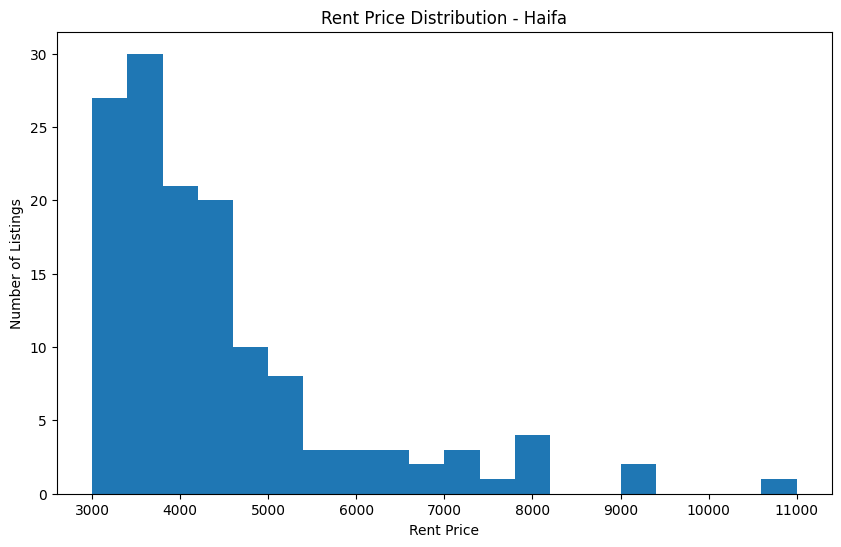

In [29]:
plt.figure(figsize=(10, 6))
plt.hist(rent_final["price"], bins=20)

plt.title(f"Rent Price Distribution - {CITY_NAME}")
plt.xlabel("Rent Price")
plt.ylabel("Number of Listings")

plt.show()

## 15. EDA - Average Rent by Neighborhood

This analysis shows which neighborhoods have the highest average rent.

In [30]:
avg_rent_neighborhood = (
    rent_neighborhood_filtered
    .groupby("Neighborhood")["price"]
    .mean()
    .sort_values(ascending=False)
)

avg_rent_neighborhood.head(10)

,price
Neighborhood,
North Carmel,6637.500000
Central Carmel,5622.727273
Yizre'eliya,4234.615385
West Carmel,4146.153846
Downtown Haifa,4075.714286
Neve Shaanan,3863.333333
Upper Hadar,3738.461538
Hadar HaCarmel,3685.185185


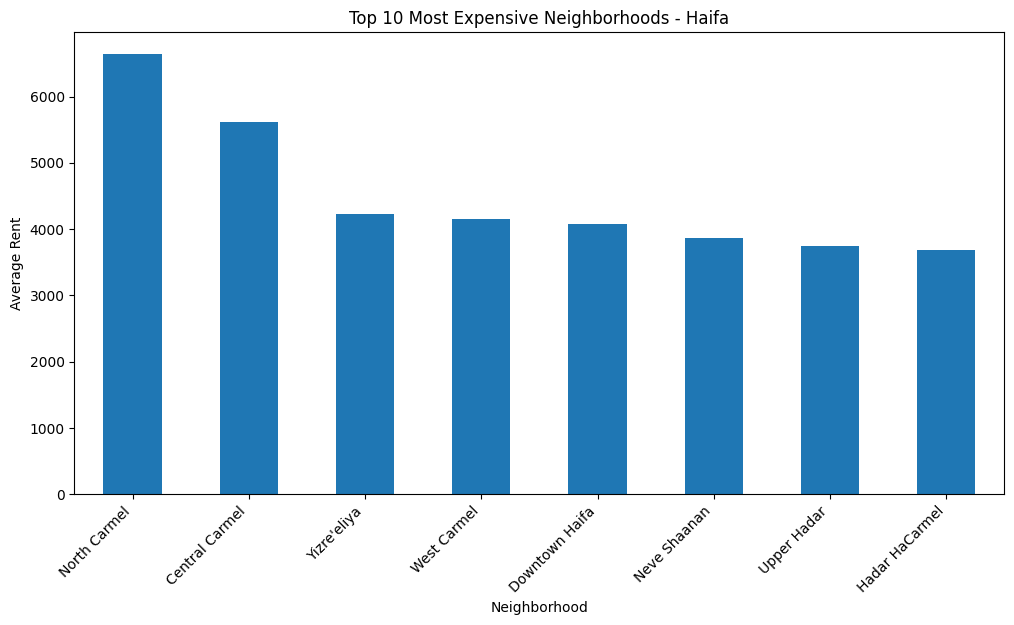

In [31]:
top_neighborhoods = avg_rent_neighborhood.head(10)

plt.figure(figsize=(12, 6))
top_neighborhoods.plot(kind="bar")

plt.title(f"Top 10 Most Expensive Neighborhoods - {CITY_NAME}")
plt.xlabel("Neighborhood")
plt.ylabel("Average Rent")

plt.xticks(rotation=45, ha="right")
plt.show()

## 16. EDA - Cheapest Neighborhoods

This analysis shows the neighborhoods with the lowest average rent.

In [32]:
cheapest_neighborhoods = (
    rent_neighborhood_filtered
    .groupby("Neighborhood")["price"]
    .mean()
    .sort_values(ascending=True)
)

cheapest_neighborhoods.head(10)

,price
Neighborhood,
Hadar HaCarmel,3685.185185
Upper Hadar,3738.461538
Neve Shaanan,3863.333333
Downtown Haifa,4075.714286
West Carmel,4146.153846
Yizre'eliya,4234.615385
Central Carmel,5622.727273
North Carmel,6637.500000


## 17. EDA - Rooms vs Rent Price

This analysis checks how rent price changes depending on the number of rooms.

In [33]:
avg_rent_by_rooms = (
    rent_final
    .groupby("rooms")["price"]
    .mean()
    .sort_values()
)

avg_rent_by_rooms

,price
rooms,
1.5,3000.000000
2.5,3510.714286
3.5,3828.666667
2.0,3996.875000
3.0,4102.040816
4.5,4883.333333
4.0,5314.666667
5.0,6050.000000
6.0,8000.000000


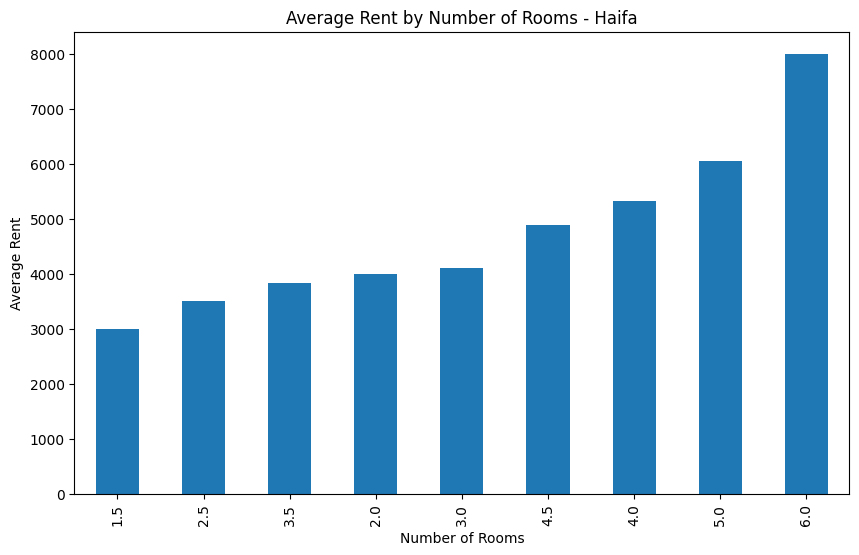

In [34]:
plt.figure(figsize=(10, 6))
avg_rent_by_rooms.plot(kind="bar")

plt.title(f"Average Rent by Number of Rooms - {CITY_NAME}")
plt.xlabel("Number of Rooms")
plt.ylabel("Average Rent")

plt.show()

## 18. EDA - Price per Square Meter

Price per square meter is useful because it allows comparison between apartments of different sizes.

In [35]:
avg_sqm_neighborhood = (
    rent_neighborhood_filtered
    .groupby("Neighborhood")["price_per_sqm"]
    .mean()
    .sort_values(ascending=False)
)

avg_sqm_neighborhood.head(10)

,price_per_sqm
Neighborhood,
Upper Hadar,292.493077
North Carmel,70.625000
Central Carmel,64.224091
West Carmel,61.450769
Downtown Haifa,58.260000
Yizre'eliya,50.993077
Hadar HaCarmel,49.156296
Neve Shaanan,47.555333


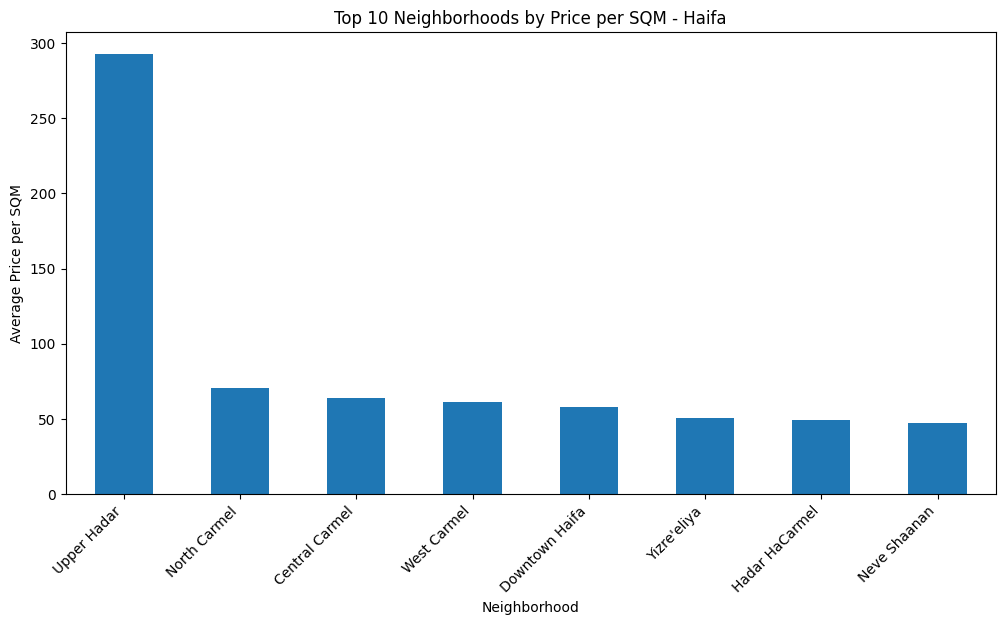

In [36]:
top_sqm_neighborhoods = avg_sqm_neighborhood.head(10)

plt.figure(figsize=(12, 6))
top_sqm_neighborhoods.plot(kind="bar")

plt.title(f"Top 10 Neighborhoods by Price per SQM - {CITY_NAME}")
plt.xlabel("Neighborhood")
plt.ylabel("Average Price per SQM")

plt.xticks(rotation=45, ha="right")
plt.show()

## 19. Export Clean Dataset

Finally, I export the cleaned dataset as a CSV file.

This file will later be combined with other city datasets.

In [37]:
# Export final clean dataset
rent_final.to_csv(OUTPUT_FILE, index=False)

print(f"File exported successfully: {OUTPUT_FILE}")

File exported successfully: haifa_rent_clean.csv


In [38]:
from google.colab import files

files.download(OUTPUT_FILE)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>